<h1>ML basics</h1>
Deep learning works by performing large‑scale numerical computation on tensor (scalars, vectors, matrices and higher‑dimensional arrays). Getting comfortable with shape, rank, dtype and a few core operations (indexing, broadcasting, matmul, reductions) prevents most bugs when building models.

Import TensorFlow (GPU/CPU numerical engine + deep learning library) and NumPy (general numerical Python library). Print the TF version. Some behaviors (e.g., default dtypes) can vary across versions.

In [1]:
import tensorflow as tf
import numpy as np

print("TF:", tf.__version__)

TF: 2.20.0


Rank = number of axes (dimensions).  
scalar has rank 0 (shape=()) > a single number;  
vector rank 1 (shape=(3,));  
matrix rank 2 (shape=(2,2));  
tensor rank 3 (shape=(2,2,1)).  
Shape = size along each axis (batch, height, width...).

  
Your models understand only numbers and shapes. 

In [2]:
# 1) Scalars, vectors, matrices, tensors
scalar = tf.constant(7)  # rank-0
vector = tf.constant([10, 20, 30]) # rank-1
matrix = tf.constant([[1., 2.], [3., 4.]])  # rank-2
tensor  = tf.constant([[[1],[2]], [[3],[4]]]) # rank-3 (2x2x1)

print(scalar.shape, vector.shape, matrix.shape, tensor.shape)

() (3,) (2, 2) (2, 2, 1)


<i>Extra task:</i><br>
What’s the rank/shape of an RGB image with 32 images 64×64 pixels?

In [3]:
img_batch = tf.zeros([32, 64, 64, 3])  # 32 images, 64×64, RGB
print(img_batch.shape, img_batch.ndim) # (32, 64, 64, 3), rank=4

(32, 64, 64, 3) 4


tf.zeros([32, 64, 64, 3]) creates a new tensor of the given shape filled with zeros. In the context of images 0 means no intensity > a completely black pixel.<br><br>
So img_batch is a batch of 32 solid‑black images, each 64×64 with 3 color channels.

In [4]:
# 2) Dtypes and casting
x = tf.constant([1.7, 7.4]) # float32 default
y = tf.constant([7, 10]) # int32 default
x16 = tf.cast(x, tf.float16) # reduced precision floats
y32 = tf.cast(y, tf.float32) # cast ints → floats

A dtype (data type) tells TensorFlow what kind of numbers a tensor stores, e.g., float32, float16, int32, or bool. It’s one of the three core properties of a tensor alongside shape and rank. The dtype you choose affects memory use and numerical precision, so it has practical consequences for speed and stability.
<br><br>
Casting changes dtype without changing shape. float16 halves memory but reduces precision. Good for speed on certain GPUs.

In [5]:
# 3) Indexing and shaping
rank2 = tf.constant([[10, 7], [3, 4]])
last_col = rank2[:, -1] # column slice
expanded = tf.expand_dims(rank2, -1) # add channel-like axis
squeezed = tf.squeeze(expanded, axis=-1)

: picks all rows. 
-1 selects the last column. last_col has shape (2,).

<b>Reshaping:</b>

expand_dims(..., -1) adds a new axis at the end: (2,2) > (2,2,1).<br>
squeeze(..., axis=-1) removes a size‑1 axis: back to (2,2).

In [6]:
# 4) Broadcasting & basic ops
A = tf.constant([[10., 7.], [3., 4.]])
print("A+10:\n", A + 10)
print("A*2:\n", A * 2)

A+10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A*2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)


Basic ops: +, * operate per position. This is different from matrix multiplication (tf.matmul).

Matmul rule: For A @ B, the inner dimensions must match: (m×n) @ (n×p) -> (m×p). So you transpose Y (from (3×2) to (2×3)) to make 2 match 2.<br><br>
Matrix multiplication is central to neural networks. 

In [7]:
# 5) Matrix multiplication rules (inner dims match)
X = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32)  # (3x2)
Y = tf.constant([[7, 8], [9, 10], [11, 12]], dtype=tf.float32) # (3x2)
XtY = tf.matmul(X, tf.transpose(Y))     # (3x2) @ (2x3) -> (3x3)

In [8]:
# 6) Aggregations
E = tf.constant(np.random.randint(0, 100, size=10))
print("min:", tf.reduce_min(E).numpy(),
      "max:", tf.reduce_max(E).numpy(),
      "mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy(),
      "sum:", tf.reduce_sum(E).numpy())


min: 22 max: 83 mean: 52.3 sum: 523


<b>Extra example  of why should we change int to float:</b>

In [9]:

M = tf.constant([[1., 2.], [3., 4.]])  # (2,2)
print(tf.reduce_mean(M, axis=0).numpy())  # column means -> [2., 3.]
print(tf.reduce_mean(M, axis=1).numpy())  # row means    -> [1.5, 3.5]

[2. 3.]
[1.5 3.5]


In [10]:
# 7) One-hot encoding
idx = tf.constant([0, 1, 2, 3])
oh  = tf.one_hot(idx, depth=4)

Each integer label becomes a vector of length depth; only the index position is 1, others 0. Example:<br>
0 -> [1,0,0,0]<br>
1 -> [0,1,0,0]

In [11]:
labels = tf.constant([2, 0, 1])
print(tf.one_hot(labels, depth=3).numpy())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


You can convert NumPy arrays <-> TensorFlow tensors easily.

In [12]:

# 8) NumPy interop
arr = np.array([3., 7., 10.])
t   = tf.constant(arr) # NumPy -> Tensor
back_to_np = t.numpy() # Tensor -> NumPy

print("OK")

OK


<h2>Regression model</h2><br>
The standard Keras workflow: Create -> Compile -> Fit -> Evaluate -> Predict -> Visualize.<br><br>
Separate train/test to measure generalization instead of memorization.

We use Matplotlib for visualization. 

In [13]:
#import tensorflow as tf
#import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Synthetic linear data
X = np.arange(-20, 21, 2, dtype=np.float32)  # [-20., -18., ..., 20.]
y = X + 10

<img src="Screenshot_function.png" alt="y=X + 10">

Split material, first 20 points for training, remaining for testing.<br><br>
Split to evaluate on data not seen during training to estimate generalization (how well the learned rule applies to new inputs).

In [15]:
# Train/test split (simple)
X_train, y_train = X[:20], y[:20]
X_test,  y_test  = X[20:], y[20:]

Read more: <a href="https://keras.io/guides/sequential_model/">Sequential model</a><br><br>
A Sequential model is Keras’s model type for a single straight pipeline: one input > layers in order > one output. It’s ideal whenever your architecture is a plain stack (no branches/merges). This includes simple regression or classification on a single input vector and single input image pipelines. 

If the task has multiple inputs (e.g., image + numeric features) or needs branching/merging, switch to the Functional API. With Functional, you can build separate layer branches, an MLP (Dense) branch for numeric features and a CNN (Conv2D/MaxPool2D) branch for images. Then merge their features (e.g., Concatenate) and finish with a linear Dense output for regression (e.g. house price depending on size + photo).

A layer takes one or more tensors in and outputs one or more tensors after applying a computation (its call method). It also holds state (weights) that training updates. Layers are the basic building blocks you stack to form models. 

API in this case means a set of classes and methods you call to build neural networks.

In [16]:
# 1) CREATE
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)  # linear output for regression
])

A loss function turns your model’s mistakes into one number so the training loop knows how “wrong” the model is right now. Keras needs this number to decide how to adjust the weights on the next step. Without a loss, the model has no target to improve.
Why we need it (practically):

Gives the optimizer a target. During model.fit, Keras computes the loss on each batch and the optimizer uses it to nudge the weights to make that number smaller next time.

Enables training with one line. model.compile(loss=..., optimizer=..., metrics=...) wires everything so Keras can run the built‑in training loop. 
Lets you compare and monitor. You can watch training vs. validation loss to see if you’re improving, plateauing, or overfitting.

In [17]:
# 2) COMPILE
model.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=["mae"]
)

model.fit(...) runs Keras’s built‑in training loop. On each epoch, the model makes predictions on batches of X_train, computes the loss against y_train, and the optimizer updates the weights to try to reduce that loss next time. The call returns a History object that contains per‑epoch logs (e.g., loss) in history.history.
epochs=200: “Try the whole dataset 200 times.” More epochs can help if the model hasn’t converged yet—but watch validation to avoid overfitting. 
<br><br>
verbose=0: hides per‑epoch printing. Use verbose=1 to show an epoch‑by‑epoch progress line, or verbose=2 to show one summary line per epoch.
<br><br>
If you want training to stop automatically when improvement stalls, add callbacks like EarlyStopping (optionally restoring the best weights). This is standard practice in Keras. 

In [18]:
# 3) FIT
history = model.fit(X_train, y_train, epochs=200, verbose=1)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - loss: 20.1323 - mae: 20.1323
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 19.2483 - mae: 19.2483
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 18.3643 - mae: 18.3643
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 17.4916 - mae: 17.4916
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 16.7163 - mae: 16.7163
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 15.9410 - mae: 15.9410
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 15.1657 - mae: 15.1657
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 14.3904 - mae: 14.3904
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 13.6474 - mae: 13.6474
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 13.0058 - mae: 13.0058
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 12.3642 - mae: 12.3642
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 11.7523 - mae: 11.7523
Epoch 13/200
1/1 ━━━━━━━

model.evaluate(...) runs the model on unseen test data and computes the loss and any metrics you set in compile. This measures generalization, not training progress.
<br><br> 
For a model compiled with a single metric (metrics=["mae"]), evaluate returns two numbers: [loss, metric]. Because here the loss is also "mae", you’ll typically see very similar values for loss and mae. Printing “Test MAE:” gives an accuracy number in target units.
<br><br>
Performance should be judged on data not used during training. This is how we check the model learned the rule (here, y = x + 10) rather than memorizing specific points.

In [19]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)


Test MAE: 16.303468704223633


model.predict(...): produces outputs for new inputs without changing weights. We squeeze to make the array 1‑D for plotting.
<br><br>
Why the plot: Numbers summarize; plots explain. Showing true test points (green) and predictions (red) over the same X_test makes it visually clear whether the learned line matches the underlying rule. This aligns with the teaching guidance in your material—visual inspection reveals bias and systematic mismatches better than a single average number.
<br><br>
What to expect here: If training went well, the red predicted points should lie close to the green test points along a line with slope = 1 and intercept = 10 (the model has learned y = x + 10). Your evaluate step’s Test MAE should be small, and the scatter should show tight overlap

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


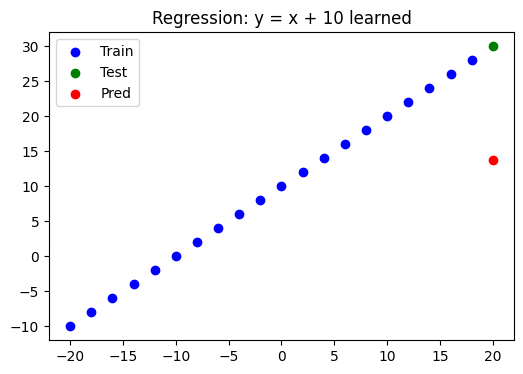

In [20]:
# Predict and visualize
y_pred = model.predict(X_test).squeeze()

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test,  y_test,  c='g', label='Test')
plt.scatter(X_test,  y_pred,  c='r', label='Pred')
plt.legend(); plt.title("Regression: y = x + 10 learned")
plt.show()

HOMEWORK: Fix the regression model

<h1>Classification</h1>

Test accuracy: 0.995


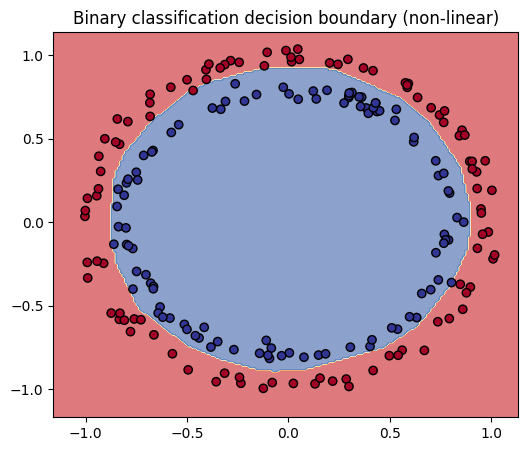

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Non-linear separable data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=0)

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
                     np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title("Binary classification decision boundary (non-linear)")
plt.show()


Test accuracy: 0.8845000267028809
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


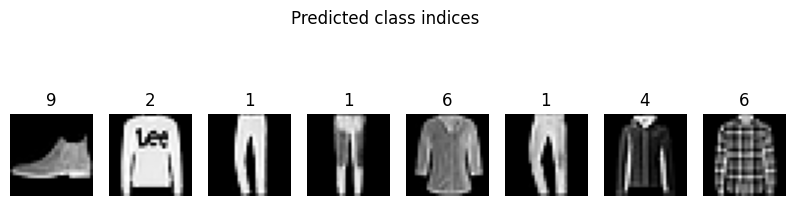

In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0

# 1) CREATE (flatten → Dense ReLU → Dense softmax)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2) COMPILE
model.compile(
    loss="sparse_categorical_crossentropy",  # labels are ints, not one-hot
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

# Show a few preds
preds = model.predict(x_test[:8]).argmax(axis=1)
plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(int(preds[i]))
    plt.axis('off')
plt.suptitle("Predicted class indices"); plt.show()


In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Use Fashion-MNIST but map 2 classes to a binary task (e.g., class 9=Ankle boot vs 7=Sneaker)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Keep only classes 7 and 9
train_mask = np.isin(y_train, [7, 9])
test_mask  = np.isin(y_test,  [7, 9])

x_train = x_train[train_mask][..., None]/255.0
y_train = (y_train[train_mask] == 9).astype(np.float32)  # 1 if class 9 else 0
x_test  = x_test[test_mask][..., None]/255.0
y_test  = (y_test[test_mask] == 9).astype(np.float32)

# 1) CREATE (small CNN)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)


Test accuracy: 0.9725000262260437


In [24]:

import tensorflow as tf
from tensorflow.keras import layers, models

# --- Data ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# cifar10 is a dataset of images with 10 classes

# Keep classes 0,1,2 only
mask_train = (y_train < 3).flatten()
mask_test  = (y_test  < 3).flatten()
# standarization of pixel values from 0-255 to 0-1
x_train = x_train[mask_train].astype("float32")/255.0
y_train = y_train[mask_train].flatten()
x_test  = x_test[mask_test].astype("float32")/255.0
y_test  = y_test[mask_test].flatten()

# --- Very small CNN model ---
model = models.Sequential([
    # convelutional layer 32 filters 3x3 pixels relu is getting rid of negative 
    # values padding keeps the inpout in the same size as output expects 
    # 32x32 RGB image as input
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)), # filter size 3*3
    # Downsamples the image in half helps with generalization and reduce computation 
    # (takes the maximal value in each 2x2 blocks)
    layers.MaxPooling2D(),

    # input shape don't need to be specified as the input and output 
    # of previous layer needs to be the same
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # Converts the feature map (3D) into vector (1D)
    layers.Flatten(),
    # 64 neurons leanrs high level combinations of features
    layers.Dense(64, activation="relu"),
    # outpu layer with 3 neurons one per class 
    # softmax converts raw scores into probabilitites that sum to 1
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam", # adaptive optimizer, adjust learning rate automactically
    loss="sparse_categorical_crossentropy", # standart loss for multi-class 
    # classification when labels are integers (not one-hot)
    metrics=["accuracy"] # metric to monitor during training 
)

# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=5, # passes through the entire dataset 5 times
    batch_size=64, # updates weights after every 64 images
    validation_split=0.1, # 10% of training data to monitor overfitting
    verbose=1 # print training progress bars
)

# --- Evaluate ---
# runs the model on unseen test set and prints accuracy
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy (tiny CNN):", acc)


c:\Reps\Spring2026\ML\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Epoch 1/5


c:\Reps\Spring2026\ML\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7275 - loss: 0.6497 - val_accuracy: 0.7893 - val_loss: 0.5276
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8356 - loss: 0.4150 - val_accuracy: 0.8760 - val_loss: 0.3439
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8694 - loss: 0.3328 - val_accuracy: 0.8913 - val_loss: 0.2990
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8873 - loss: 0.2872 - val_accuracy: 0.8953 - val_loss: 0.2787
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9056 - loss: 0.2473 - val_accuracy: 0.9087 - val_loss: 0.2529
Test accuracy (tiny CNN): 0.8889999985694885


Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)


c:\Reps\Spring2026\ML\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3333 - loss: 1.0597 - val_accuracy: 0.3229 - val_loss: 1.0291
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5573 - loss: 0.9860 - val_accuracy: 0.6667 - val_loss: 0.9576
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6745 - loss: 0.9130 - val_accuracy: 0.6667 - val_loss: 0.8829
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6745 - loss: 0.8357 - val_accuracy: 0.6667 - val_loss: 0.8066
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6745 - loss: 0.7613 - val_accuracy: 0.6667 - val_loss: 0.7357
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6745 - loss: 0.6948 - val_accuracy: 0.6667 - val_loss: 0.6747
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6745 - loss: 0.6368 - val_accuracy: 0.6667 - val_loss: 0.6182
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8438 - loss: 0.5739 - val_accuracy: 1.0000 - val_loss: 0.5493

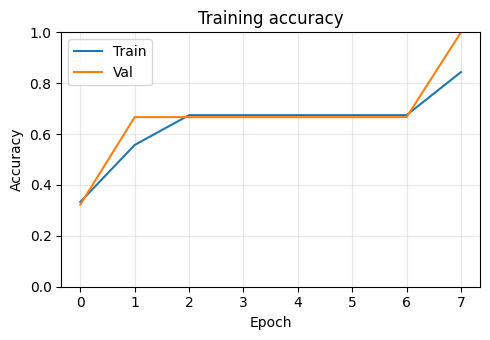

Test accuracy: 1.000
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


FileNotFoundError: No such file or directory: 'mlp_tiny.png'

FileNotFoundError: No such file or directory: 'mlp_tiny.png'

<IPython.core.display.Image object>

In [25]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data

def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32) # creates 8x8 black image
    # draw the pattern depending on the label
    if label == 0:         # vertical bar
        img[:, 3] = 1.0 
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)

    # adds normal distribution noise to the images
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0) # clip keeps all values in [0,1]

# generates 200 samples per class
# 3 classes * 200 = 600
n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

# Keras expects images as height width channels
# [..., np.newaxis] adds a channel dimension
X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
# Shuffles all samples to not keep all of the classes next to each other
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
# 80 to 20 train test split
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# Small MLP model
model = keras.Sequential([
    # flattens the 8x8x1 image into a 64 element vector (1D)
    layers.Flatten(input_shape=(8, 8, 1)),  # (None, 64) — no params
    # 8 neuorons each takes the 64 inputs plus bias
    layers.Dense(8, activation="relu"),     # 64*8 + 8 = 520 params
    # 8 inputs for every neuron (3) plus bias
    # output layer 3 neurons softmax turn scores into probabilitites
    layers.Dense(3, activation="softmax")   # 8*3 + 3 = 27 params
])

model.compile(
    optimizer="adam", # adaptive optimizer, adjust learning rate automactically
    loss="sparse_categorical_crossentropy", # standart loss for multi-class 
    # classification when labels are integers (not one-hot)
    metrics=["accuracy"] # metric to monitor during training 
)

# prints table of all layers and parameter counts
model.summary()

# Train
history = model.fit(
    x_train, y_train,
    epochs=8, 
    batch_size=32, # updates weights after 32 images
    validation_split=0.2,# 20% of data for validation
    verbose=1
)

# Plot accuracy (train vs val)
plt.figure(figsize=(5,3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy")
plt.tight_layout()
plt.show()

# Evaluate on test set
# run the model on unseen data
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Plot the model diagram
# saves visual diagram of the model architectire as PNG and displays it inline
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
plot_model(model, to_file="mlp_tiny.png")
display(Image("mlp_tiny.png"))


Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)


Model: "tiny_parallel_mlp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 8, 8, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchA_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchB_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 8)         │          0 │ branchA_dense[0]… │
│ (Concatenate)       │                   │            │ branchB_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         27 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2448 - loss: 1.1129 - val_accuracy: 0.4583 - val_loss: 1.0540
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5859 - loss: 1.0239 - val_accuracy: 0.6979 - val_loss: 0.9747
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6693 - loss: 0.9454 - val_accuracy: 0.7188 - val_loss: 0.9024
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8047 - loss: 0.8729 - val_accuracy: 0.9896 - val_loss: 0.8337
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.8028 - val_accuracy: 1.0000 - val_loss: 0.7663
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.7349 - val_accuracy: 1.0000 - val_loss: 0.7018
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.6706 - val_accuracy: 1.0000 - val_loss: 0.6392
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.6081 - val_accuracy: 1.0000 - val_loss: 0.5783

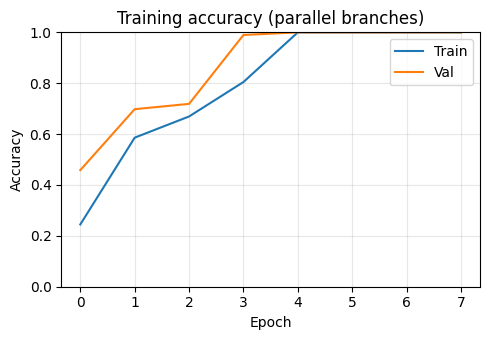

Test accuracy: 1.000
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


FileNotFoundError: No such file or directory: 'parallel_mlp.png'

FileNotFoundError: No such file or directory: 'parallel_mlp.png'

<IPython.core.display.Image object>

In [26]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data
def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)
# ^^^^^^^^^^^^^^^^The same as in previous block^^^^^^^^^^^^^^^^

# Parallel-branches MLP (Functional API)
inputs = keras.Input(shape=(8, 8, 1), name="input") # defining the input 8x8x1
# Both branches will read from the flattend vector x
# In functional API you call the layer like a function passing the previous tensor as argument
# in plain words you add the () with the previous layer at the end
x = layers.Flatten(name="flatten")(inputs)          # (None, 64) — params: 0

# both branches A and B take the same input x but have seperate weights
# Branch A: Dense(4)
branch_a = layers.Dense(4, activation="relu", name="branchA_dense")(x)  # params: 64*4 + 4 = 260

# Branch B: Dense(4)
branch_b = layers.Dense(4, activation="relu", name="branchB_dense")(x)  # params: 64*4 + 4 = 260

# Concatenate takes the two 4 element vectors from the branch A and B and creates one 8 element vector
# In this case [a1,a2,...,b1,...]
# there are other options to merge two layers for example Add, Average, Multiply
# Merge (concatenate)
merged = layers.Concatenate(name="concat")([branch_a, branch_b])

# takes 8 element vecotr  -> 3 class probabilities
# Output: Dense(3)
outputs = layers.Dense(3, activation="softmax", name="output")(merged)  # params 8x3 + 3 = 27

model = keras.Model(inputs, outputs, name="tiny_parallel_mlp")
# Unlike `keras.Sequential`, here you explicitly pass the **entry point** (`inputs`) and 
# **exit point** (`outputs`). Keras traces all connections in between to build the full graph.
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# Train
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy
plt.figure(figsize=(5,3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy (parallel branches)")
plt.tight_layout()
plt.show()

# Evaluate on test set
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Plot the model diagram
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
plot_model(model, to_file="parallel_mlp.png")
display(Image("parallel_mlp.png"))


In [27]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data
def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)
# ^^^^^^^^^^^^^^^^The same as in previous block^^^^^^^^^^^^^^^^

# MLP model 
model = keras.Sequential([
    layers.Flatten(input_shape=(8, 8, 1)),  # (None, 64) — 0 params
    layers.Dense(8, activation="relu"),     # 64*8 + 8 = 520 params
    layers.Dense(3, activation="softmax")   # 8*3 + 3 = 27 params
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train
history = model.fit(
    x_train, y_train,
    epochs=6,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Save to a .keras file
save_path = "miras_model.keras"
# saves everything cructial to reconstruct the model:
# architecture - layers structure and how they are connected
# weights - the learned parameters
# optimizer state - to resume training where you left off
# compile cofig loss function, metrics, optimizer type
model.save(save_path)
# converts relatice path to a absolute path
print("Saved model to:", os.path.abspath(save_path))

Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)
Epoch 1/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5339 - loss: 1.0735 - val_accuracy: 0.6667 - val_loss: 0.9937
Epoch 2/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6745 - loss: 0.9303 - val_accuracy: 0.6771 - val_loss: 0.8594
Epoch 3/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8880 - loss: 0.8051 - val_accuracy: 1.0000 - val_loss: 0.7454
Epoch 4/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.7072 - val_accuracy: 1.0000 - val_loss: 0.6606
Epoch 5/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.6283 - val_accuracy: 1.0000 - val_loss: 0.5874
Epoch 6/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.5581 - val_accuracy: 1.0000 - val_loss: 0.5215
Test accuracy: 1.000
Saved model to: c:\Reps\Spring2026\ML\miras_model.keras


In [28]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Recreate the same simple dataset
np.random.seed(0)
tf.random.set_seed(0)

def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:
        img[:, 3] = 1.0
    elif label == 1:
        img[3, :] = 1.0
    else:
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Same split as before
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]
# ^^^^^^^^^^^^^^^^The same as in previous block^^^^^^^^^^^^^^^^

# reads the .keras file from disk and fully reconstructs the model
# Load the saved .keras file
loaded_model = keras.models.load_model("miras_model.keras")
# confirms the resotred architecture looks correct
loaded_model.summary()

# it should be exaclty the same as in the orginal model
# Evaluate the loaded model
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model - test accuracy: {acc:.3f}")

# Predict a few samples
probs = loaded_model.predict(x_test[:5], verbose=0)  # shape: (5, 3)
preds = probs.argmax(axis=1)
print("Predictions:", preds)
print("True labels:", y_test[:5].tolist())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,643 (6.42 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,096 (4.29 KB)

Loaded model - test accuracy: 1.000
Predictions: [2 1 0 2 2]
True labels: [2, 1, 0, 2, 2]


In [29]:
def optimazationAccuracyCheck(history):

    trainLoss = np.array(history.history['loss'])
    valLoss = np.array(history.history['val_loss'])
    trainAcc = np.array(history.history['accuracy'])
    valAcc = np.array(history.history['val_accuracy'])

    plt.figure(figsize=(8, 5))
    plt.scatter(trainLoss, trainAcc, label='Training', color='blue', alpha=0.7)
    plt.scatter(valLoss, valAcc, label='Validation', color='orange', alpha=0.7)
    plt.xlabel('Loss (Optimization Progress)')
    plt.ylabel('Accuracy')
    plt.title('(Optimization vs Accuracy)')
    plt.legend()
    plt.grid(True)
    plt.show()

    corr_train = np.corrcoef(trainLoss, trainAcc)[0,1]
    corr_val = np.corrcoef(valLoss, valAcc)[0,1]
    print(f'Correlation (Train loss vs. Accuracy): {corr_train:.3f}')
    print(f'Correlation (Val loss vs. Accuracy): {corr_val:.3f}')

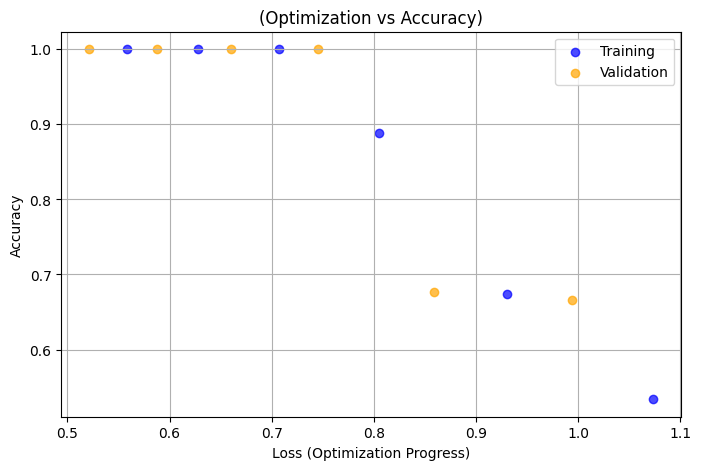

Correlation (Train loss vs. Accuracy): -0.959
Correlation (Val loss vs. Accuracy): -0.878


In [30]:
optimazationAccuracyCheck(history)

Looking at this graph the tendency was correct (going into upper left corner) but it is not looking as good as in my exam file. I would guess it is casued by small amount of epochs. Getting into the numbers training lass anc accuracy coefficient is very good counter proportional relation is what we are aiming vallidation loss and accuracy is not as good as in training but it is still good.